# Работа со строковыми значениями

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Работа со строковыми значениям"
* https://pyformat.info/
* https://docs.python.org/3/library/re.html
    * https://docs.python.org/3/library/re.html#flags
    * https://docs.python.org/3/library/re.html#functions
* https://pythonru.com/primery/primery-primeneniya-regulyarnyh-vyrazheniy-v-python
* https://kanoki.org/2019/11/12/how-to-use-regex-in-pandas/
* https://realpython.com/nltk-nlp-python/

## Задачи для совместного разбора

1. Вывести на экран данные из словаря `obj` построчно в виде `k = v`, задав формат таким образом, чтобы знак равенства оказался на одной и той же позиции во всех строках. Строковые литералы обернуть в кавычки.

In [1]:
obj = {
    "home_page": "https://github.com/pypa/sampleproject",
    "keywords": "sample setuptools development",
    "license": "MIT",
}

2. Написать регулярное выражение,которое позволит найти номера групп студентов.

In [3]:
import pandas as pd

In [4]:
obj = pd.Series(["Евгения гр.ПМ19-1", "Илья пм 20-4", "Анна 20-3"])
obj

0    Евгения гр.ПМ19-1
1         Илья пм 20-4
2            Анна 20-3
dtype: object

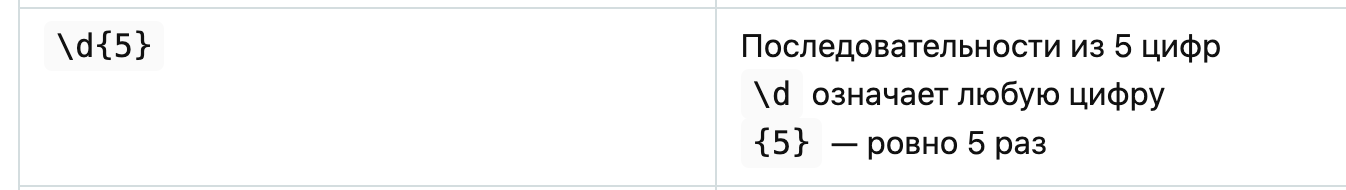

In [5]:
import re

pattern = r"\d{2}-\d" # "\d{2}-\d" - две цифры, дефис, одна цифра
obj.str.findall(pattern)

0    [19-1]
1    [20-4]
2    [20-3]
dtype: object

3. Разбейте текст формулировки задачи 2 на слова.

In [7]:
# Разбейте текст формулировки задачи 2 на слова.

pattern = r"\w+" # "\w+" - один или более символов, включая цифры и знак подчеркивания
obj.str.findall(pattern)

0    [Евгения, гр, ПМ19, 1]
1         [Илья, пм, 20, 4]
2             [Анна, 20, 3]
dtype: object

## Лабораторная работа 6

### Форматирование строк

1\. Загрузите данные из файла `recipes_sample.csv` (__ЛР2__) в виде `pd.DataFrame` `recipes` При помощи форматирования строк выведите информацию об id рецепта и времени выполнения 5 случайных рецептов в виде таблицы следующего вида:

    
    |      id      |  minutes  |
    |--------------------------|
    |    61178     |    65     |
    |    202352    |    80     |
    |    364322    |    150    |
    |    26177     |    20     |
    |    224785    |    35     |
    
Обратите внимание, что ширина столбцов заранее неизвестна и должна рассчитываться динамически, в зависимости от тех данных, которые были выбраны. 

In [8]:
import pandas as pd

recipes = pd.read_csv("02_pandas_data/recipes_sample.csv")
recipes.head()


,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,george s at the cove black bean soup,44123,90,35193,2002-10-25,NaN,an original recipe created by chef scott meska...,18.0
1,healthy for them yogurt popsicles,67664,10,91970,2003-07-26,NaN,my children and their friends ask for my homem...,NaN
2,i can t believe it s spinach,38798,30,1533,2002-08-29,NaN,"these were so go, it surprised even me.",8.0
3,italian gut busters,35173,45,22724,2002-07-27,NaN,my sister-in-law made these for us at a family...,NaN
4,love is in the air beef fondue sauces,84797,25,4470,2004-02-23,4.0,i think a fondue is a very romantic casual din...,NaN


2\. Напишите функцию `show_info`, которая по данным о рецепте создает строку (в смысле объекта python) с описанием следующего вида:

```
"Название Из Нескольких Слов"

1. Шаг 1
2. Шаг 2
----------
Автор: contributor_id
Среднее время приготовления: minutes минут
```

    
Данные для создания строки получите из файлов `recipes_sample.csv` (__ЛР2__) и `steps_sample.xml` (__ЛР3__). 
Вызовите данную функцию для рецепта с id `170895` и выведите (через `print`) полученную строку на экран.

In [13]:
assert (
    show_info(
        name="george s at the cove black bean soup",
        steps=[
            "clean the leeks and discard the dark green portions",
            "cut the leeks lengthwise then into one-inch pieces",
            "melt the butter in a medium skillet , med",
        ],
        minutes=90,
        author_id=35193,
    )
    == '"George S At The Cove Black Bean Soup"\n\n1. Clean the leeks and discard the dark green portions\n2. Cut the leeks lengthwise then into one-inch pieces\n3. Melt the butter in a medium skillet , med\n----------\nАвтор: 35193\nСреднее время приготовления: 90 минут\n'
)

<IPython.core.display.Javascript object>

## Работа с регулярными выражениями

3\. Напишите регулярное выражение, которое ищет следующий паттерн в строке: число (1 цифра или более), затем пробел, затем слова: hour или hours или minute или minutes. Произведите поиск по данному регулярному выражению в каждом шаге рецепта с id 25082. Выведите на экран все непустые результаты, найденные по данному шаблону.

In [19]:
pattern = r"\d+\s\b(hour|hours|minute|minutes)\b"
recipes[recipes["id"] == 25082]["description"].str.findall(pattern)

2415    []
Name: description, dtype: object

In [17]:
pattern = r"\d+\s\b(hour|hours|minute|minutes)\b"
recipes["description"].str.findall(pattern).dropna()

0        []
1        []
2        []
3        []
4        []
         ..
29995    []
29996    []
29997    []
29998    []
29999    []
Name: description, Length: 29377, dtype: object

4\. Напишите регулярное выражение, которое ищет шаблон вида "this..., but" _в начале строки_ . Между словом "this" и частью ", but" может находиться произвольное число букв, цифр, знаков подчеркивания и пробелов. Никаких других символов вместо многоточия быть не может. Пробел между запятой и словом "but" может присутствовать или отсутствовать.

Используя строковые методы `pd.Series`, выясните, для каких рецептов данный шаблон содержится в тексте описания. Выведите на экран количество таких рецептов и 3 примера подходящих описаний (текст описания должен быть виден на экране полностью).

In [ ]:
# Напишите регулярное выражение, которое ищет шаблон вида "this..., but" _в начале строки_ . 
# Между словом "this" и частью ", but" может находиться произвольное число букв, цифр, знаков подчеркивания и пробелов. 
#Никаких других символов вместо многоточия быть не может. Пробел между запятой и словом "but" может присутствовать или отсутствовать.

pattern = r"^this\w+\s*,\s*but"

# Используя строковые методы `pd.Series`, выясните, для каких рецептов данный шаблон содержится в тексте описания. 
# Выведите на экран количество таких рецептов и 3 примера подходящих описаний (текст описания должен быть виден на экране полностью).



5\. В текстах шагов рецептов обыкновенные дроби имеют вид "a / b". Используя регулярные выражения, уберите в тексте шагов рецепта с id 72367 пробелы до и после символа дроби. Выведите на экран шаги этого рецепта после их изменения.

### Сегментация текста

6\. Разбейте тексты шагов рецептов на слова при помощи пакета `nltk`. Посчитайте и выведите на экран кол-во уникальных слов среди всех рецептов. Словом называется любая последовательность алфавитных символов (для проверки можно воспользоваться `str.isalpha`). При подсчете количества уникальных слов не учитывайте регистр.

7\. Разбейте описания рецептов из `recipes` на предложения при помощи пакета `nltk`. Найдите 5 самых длинных описаний (по количеству _предложений_) рецептов в датасете и выведите строки фрейма, соответствующие этим рецептами, в порядке убывания длины.

8\. Напишите функцию, которая для заданного предложения выводит информацию о частях речи слов, входящих в предложение, в следующем виде:
```
PRP   VBD   DT      NNS     CC   VBD      NNS        RB   
 I  omitted the raspberries and added strawberries instead
``` 
Для определения части речи слова можно воспользоваться `nltk.pos_tag`.

Проверьте работоспособность функции на названии рецепта с id 241106.

Обратите внимание, что часть речи должна находиться ровно посередине над соотвествующим словом, а между самими словами должен быть ровно один пробел.
